# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective

The purpose of this analysis is to investigate how Bitcoin market sentiment influences trader behavior and performance on Hyperliquid.

By combining historical trading data with the Bitcoin Fear & Greed Index, I aim to identify patterns in profitability, trading activity, and risk-taking behavior under different market conditions.

The analysis focuses on answering the following questions:

* Does trader profitability vary across different sentiment conditions?
* How does trading activity change during Fear and Greed periods?
* Are traders taking larger positions under certain sentiment conditions?
* Can market sentiment provide useful signals for trading decisions?

In [3]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


## Dataset Overview

The analysis uses two datasets. The first dataset contains historical trading activity from Hyperliquid, including trade size, profit and loss, fees, and account-level information. The second dataset contains the Bitcoin Fear & Greed Index, which reflects overall market sentiment on a daily basis.

To understand how sentiment affects trading behavior, both datasets will be combined using their date information. This will allow performance metrics such as profitability, win rate, and trading activity to be analyzed under different market conditions.

In [4]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [5]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

## Data Quality Check

A missing value assessment was performed on both datasets before beginning the analysis.

No missing values were found in either the trading dataset or the sentiment dataset. This indicates that the data is complete and suitable for further analysis without requiring additional preprocessing steps such as imputation or row removal.

Having complete data helps ensure that any insights generated are based on the full available trading history and sentiment records.

In [7]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
).dt.date

sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

In [8]:
trades[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [9]:
merged = pd.merge(
    trades,
    sentiment[["date", "classification"]],
    left_on="Date",
    right_on="date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed


In [10]:
merged.shape

(211224, 19)

## Data Integration

To analyze the relationship between market sentiment and trading performance, the trading dataset was merged with the Bitcoin Fear & Greed Index using the trade date.

The merged dataset contains 211,224 trading records along with their corresponding market sentiment classification. This integration enables direct comparison of trader behavior and performance under different sentiment conditions such as Fear, Greed, Extreme Fear, and Extreme Greed.

In [11]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

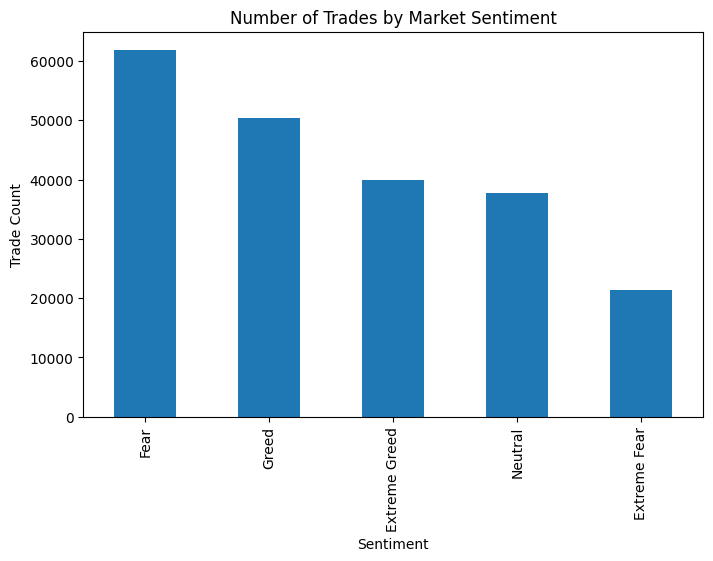

In [12]:
plt.figure(figsize=(8,5))

merged["classification"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Trade Count")

plt.show()

## Trading Activity Across Market Sentiments

To understand how trader participation varies under different market conditions, the number of trades was analyzed across each sentiment category.

Fear accounted for the highest number of trades (61,837), followed by Greed (50,303) and Extreme Greed (39,992). Neutral market conditions recorded 37,686 trades, while Extreme Fear had the lowest trading activity with 21,400 trades.

This suggests that traders remain highly active during both Fear and Greed periods. However, trading activity declines significantly during Extreme Fear conditions, indicating that many participants may become more cautious when market uncertainty reaches extreme levels.

In [13]:
pnl_summary = merged.groupby(
    "classification"
)["Closed PnL"].agg(
    ["count","mean","median","sum"]
)

pnl_summary

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06


## Profitability Analysis Across Market Sentiments

To evaluate trader performance under different market conditions, the realized profit and loss (Closed PnL) was analyzed across all sentiment categories.

Fear periods generated the highest total profit, with cumulative trader profits exceeding 3.35 million. Extreme Greed followed with approximately 2.72 million in total profits, while Greed generated around 2.15 million. Neutral and Extreme Fear conditions produced comparatively lower total profits.

When examining average profit per trade, Extreme Greed recorded the highest value at 67.89, followed by Fear at 54.29 and Greed at 42.74. Neutral and Extreme Fear exhibited the lowest average profitability.

These results suggest that trader performance is influenced by market sentiment. While Fear periods generated the largest overall profits due to higher trading activity, Extreme Greed delivered the highest average profit per trade, indicating that strong bullish market conditions may create opportunities for larger gains.

### Key Observation

An interesting pattern emerges when comparing Fear and Extreme Greed conditions.

Fear generated the highest total profit because it contained the largest number of trades. However, Extreme Greed achieved the highest average profit per trade despite having fewer trades.

This indicates that traders appear to participate more frequently during Fear periods, while trades executed during Extreme Greed tend to be more profitable on average.

Such behavior suggests that market optimism may improve trade outcomes, whereas market uncertainty encourages higher trading activity but not necessarily higher returns per trade.

In [14]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby(
    "classification"
)["Win"].mean() * 100

win_rate.sort_values(ascending=False)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Win, dtype: float64

## Win Rate Analysis

To measure trading consistency, a win rate metric was calculated by identifying trades with a positive realized profit and loss.

Extreme Greed recorded the highest win rate at 46.49%, significantly outperforming all other sentiment categories. Fear followed with a win rate of 42.08%, while Neutral, Greed, and Extreme Fear produced lower success rates of 39.70%, 38.48%, and 37.06% respectively.

The results indicate that traders were most successful during periods of Extreme Greed. In contrast, Extreme Fear produced the lowest win rate, suggesting that highly uncertain market conditions make profitable trading more difficult.

These findings highlight a clear relationship between market sentiment and trade outcomes, with bullish sentiment environments generally supporting a higher probability of successful trades.

### Trading Insight

The analysis reveals that Extreme Greed not only produced the highest average profit per trade but also delivered the highest win rate.

This combination suggests that strong bullish market sentiment may create favorable trading conditions where traders can achieve both higher profitability and greater consistency.

On the other hand, Extreme Fear generated the lowest win rate and among the lowest average profits, indicating that traders face greater uncertainty and increased difficulty in identifying successful opportunities during highly pessimistic market conditions.

From a risk management perspective, traders may benefit from adopting more conservative strategies during Extreme Fear periods while remaining disciplined during strong bullish trends.

In [15]:
size_analysis = merged.groupby(
    "classification"
)["Size USD"].mean()

size_analysis.sort_values(ascending=False)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

## Position Size Analysis

To understand how risk-taking behavior changes across market conditions, the average position size was analyzed for each sentiment category.

Fear recorded the highest average position size at approximately 7,816 USD per trade. Greed followed with an average position size of 5,737 USD, while Extreme Fear and Neutral conditions averaged 5,350 USD and 4,783 USD respectively.

Surprisingly, Extreme Greed exhibited the smallest average position size at approximately 3,112 USD per trade.

This finding suggests that traders do not necessarily increase position sizes during highly optimistic market conditions. Instead, traders appear to commit larger amounts of capital during Fear periods, potentially viewing market pullbacks as buying opportunities or attempting to capitalize on perceived undervaluation.

### Hidden Pattern: Higher Risk During Fear

A notable behavioral pattern emerges when comparing profitability and position sizing.

Although Extreme Greed produced the highest average profit per trade and the highest win rate, traders allocated the smallest average position sizes during these periods.

Conversely, Fear periods recorded the largest average position sizes despite delivering lower average profits than Extreme Greed.

This suggests that traders may become more aggressive during fearful market conditions and more cautious during strongly bullish conditions. Such behavior could reflect a tendency to accumulate positions when prices are perceived as discounted.

In [16]:
top_traders = merged.groupby(
    "Account"
)["Closed PnL"].sum().sort_values(
    ascending=False
).head(10)

top_traders

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

## Top Trader Analysis

To understand the distribution of profitability, the top-performing accounts were identified based on cumulative realized profit and loss.

The most profitable account generated approximately 2.14 million in total realized profit, significantly outperforming all other participants. The second-highest account earned approximately 1.60 million, while the remaining top traders recorded profits ranging from approximately 379 thousand to 940 thousand.

The concentration of profits among a relatively small group of accounts suggests that trading performance is not evenly distributed across participants. A limited number of highly successful traders appear to capture a substantial share of the total profits generated within the dataset.

This pattern is commonly observed in financial markets, where a small percentage of participants consistently outperform the broader trading population.

# Key Findings

1. Fear was the most active sentiment category, accounting for 61,837 trades, while Extreme Fear recorded the lowest trading activity.

2. Fear generated the highest cumulative profit, exceeding 3.35 million in total realized gains.

3. Extreme Greed produced the highest average profit per trade at 67.89, indicating stronger profitability on individual trades.

4. Extreme Greed achieved the highest win rate at 46.49%, while Extreme Fear produced the lowest win rate at 37.06%.

5. Traders allocated the largest average position sizes during Fear periods and the smallest position sizes during Extreme Greed periods.

6. Profitability was concentrated among a relatively small number of accounts, with the top trader generating more than 2.14 million in realized profit.

# Trading Recommendations

Based on the observed relationship between market sentiment and trader performance, several practical insights emerge.

1. Strong bullish market conditions may provide favorable trading opportunities, as Extreme Greed delivered both the highest average profit per trade and the highest win rate.

2. Extreme Fear periods appear to be more challenging environments for traders, suggesting that stricter risk management measures may be beneficial during highly pessimistic market conditions.

3. Larger position sizes during Fear periods indicate increased risk exposure. Traders should carefully manage position sizing when market uncertainty is elevated.

4. Monitoring market sentiment can provide additional context for decision-making, particularly when adjusting risk levels and trade selection criteria.

5. Consistently profitable traders may benefit from disciplined position management rather than relying solely on prevailing market sentiment.

# Conclusion

This study examined the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Bitcoin Fear & Greed Index.

The analysis revealed that market sentiment has a measurable impact on trading behavior, profitability, and risk-taking patterns. Fear periods generated the highest trading activity and total profits, while Extreme Greed delivered the strongest average profitability and highest win rates.

Additionally, traders appeared to allocate larger position sizes during Fear conditions despite achieving better trade outcomes during Extreme Greed periods. This behavioral pattern suggests that market participants adjust their risk exposure differently across sentiment environments.

Overall, the findings demonstrate that sentiment can serve as a valuable contextual indicator when evaluating trading opportunities and managing risk in cryptocurrency markets.